In [5]:
#############################################
"""
1. This file Generate the Dataset for training
"""

'\n1. This file Generate the Dataset for training\n'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# add parent folder (production) to sys.path
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.LoRa import LoRa

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [7]:
fs = 1e6   # 1 MHz
bw = 125e3          # LoRa Bandwidth (125 kHz)
sf = 9       # Spreading Factor 

symbol_time = 2**sf / bw  # Symbol duration
N = 2**sf

lora_init = LoRa(sf, bw)

In [8]:
# GENERATE NEW DATASET (ONCE)
GEENRATE_ = True
SNR_first = 15
SNR_last = -30

if (GEENRATE_):

    folder_path = "dataset_new_sf9"

    # Check if folder exists, if not create it
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder created: {folder_path}")
    else:
        print(f"Folder already exists: {folder_path}")
    # Outer loop: from 15 to -30 (inclusive)
    for i in range(SNR_first, SNR_last, -1):  # step -1 to count down
        # Inner loop: 100 iterations
        for j in range(512): # 0 until 511
            x1 = lora_init.gen_symbol_fs(j, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6
            snr = i
            x = lora_init.awgn_iq(x1,snr)
            #### DOWNSAMPLING
            x_ds,fs_new = downsampling(x,fs,4)
            create_spectrogram_npy(x_ds,fs_new,i,j,1,"dataset_new_sf9")
       

Folder created: dataset_new_sf9


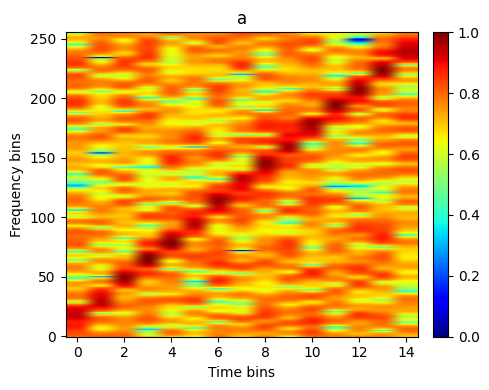

(256, 15)
float64
[[0.79768018 0.81233274 0.80580401 ... 0.77036772 0.77412646 0.71063337]
 [0.8189175  0.80346438 0.80738546 ... 0.73221288 0.76926872 0.71748366]
 [0.830832   0.78696787 0.80099624 ... 0.71088263 0.75057042 0.73419035]
 ...
 [0.66086159 0.7847836  0.77706227 ... 0.55647972 0.73083028 0.79788012]
 [0.56882553 0.79341442 0.77130709 ... 0.60356587 0.69792612 0.79086771]
 [0.50539193 0.78991944 0.745333   ... 0.63490691 0.66427259 0.79267439]]


In [9]:
file_path = "dataset_new_sf9/s_sf9_bw125_-10_0_1.npy"  # example path
data = np.load(file_path)

show_multiple_spectrograms([data],["a"],1)
print(data.shape)
print(data.dtype)
print(data)